In [2]:
# Load libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.dates import MonthLocator
import matplotlib.ticker as mtick
import os
import json
import sys
import datetime
from datetime import date
from matplotlib.dates import MO, WeekdayLocator, MonthLocator, YearLocator
from datetime import datetime, UTC, date
from matplotlib.ticker import FuncFormatter
import matplotlib.dates as mdates
from matplotlib.dates import AutoDateLocator, ConciseDateFormatter, MO
from IPython.display import HTML
from matplotlib.ticker import PercentFormatter, StrMethodFormatter

plots_filepath = 'plots/august-25/'

# Append utils to path for logo import
sys.path.append("utils")
from logo import add_logo

def format_date_with_suffix(date_obj):
    # 1) turn str or datetime/date into a pd.Timestamp
    ts = pd.to_datetime(date_obj)

    # 2) get the day and compute the ordinal suffix
    day = ts.day
    if 10 <= day % 100 <= 20:
        suffix = 'th'
    else:
        suffix = {1: 'st', 2: 'nd', 3: 'rd'}.get(day % 10, 'th')

    # 3) build the final string
    #    Month name: ts.strftime('%B')
    #    Day + suffix: f'{day}{suffix}'
    #    Year: ts.year
    return f"{ts.strftime('%B')} {day}{suffix}, {ts.year}"


today = datetime.today()
date = format_date_with_suffix(today)

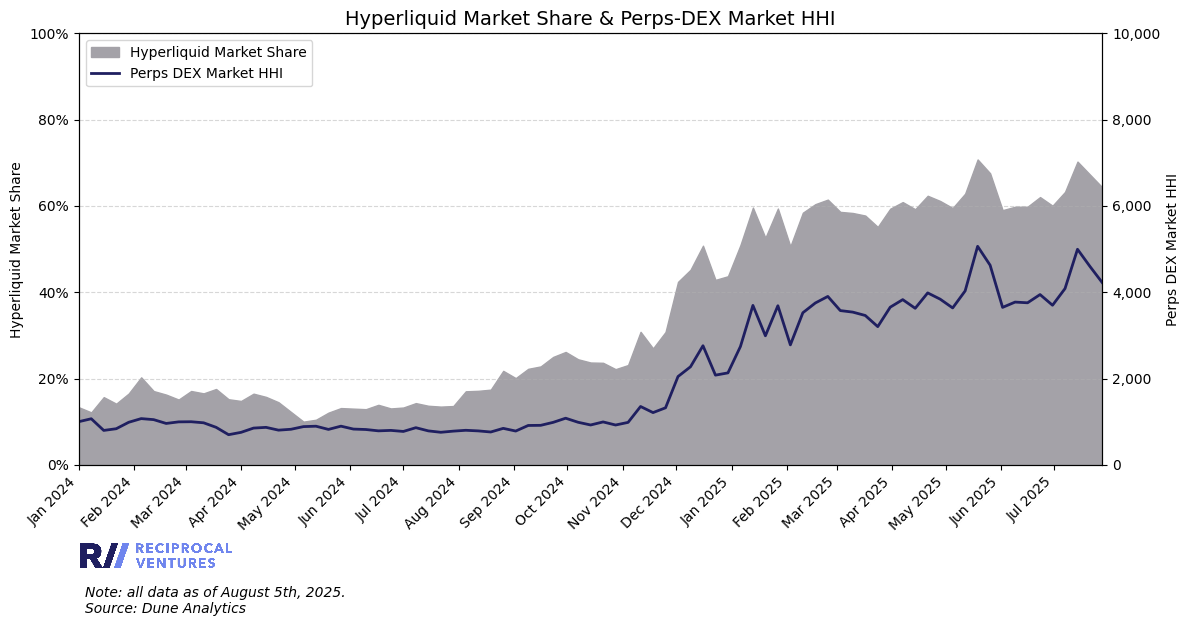

In [3]:
def plot_perpetual_volumes_from_json(json_path):
    # Load & parse the weekly JSON
    with open(json_path, 'r') as f:
        js = json.load(f)
    rows = js['result']['rows']
    df_w = pd.DataFrame(rows)
    # parse week → datetime
    df_w['date'] = pd.to_datetime(df_w['week'], utc=True)
    
    # Pivot so each row is a week, each column a product
    weekly = (
        df_w
        .pivot_table(
            index='date',
            columns='product_name',
            values='volume',
            aggfunc='sum'
        )
        .fillna(0)
    )
    
    # Compute total weekly volume & drop any weeks with zero total
    weekly['total_volume'] = weekly.sum(axis=1)
    weekly = weekly[weekly['total_volume'] > 0]

    # Market share (Hyperliquid) & HHI
    weekly['market_share'] = weekly['Hyperliquid Perps'] / weekly['total_volume'] * 100
    shares = weekly.drop(columns=['total_volume','market_share']).div(weekly['total_volume'], axis=0) * 100
    weekly['hhi'] = (shares ** 2).sum(axis=1)
    plot_df = weekly

    # Filter by index
    plot_df = plot_df[plot_df.index >= pd.to_datetime('2024-01-01', utc=True)]

    # Plot
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Area: Hyperliquid 7-week avg share
    ax1.fill_between(
        plot_df.index, plot_df['market_share'],
        color="#a4a2a8", alpha=1,
        label="Hyperliquid Market Share"
    )
    ax1.set_ylabel("Hyperliquid Market Share")
    ax1.set_ylim(0, 100)
    ax1.yaxis.set_major_formatter(PercentFormatter())

    # X-axis from first → last
    ax1.set_xlim(plot_df.index[0], plot_df.index[-1])
    ax1.margins(x=0)
    fig.subplots_adjust(left=0.07)

    # Monthly tick locator & formatter
    ax1.xaxis.set_major_locator(MonthLocator())
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")

    # Line: Perps-DEX HHI
    ax2 = ax1.twinx()
    ax2.plot(
        plot_df.index, plot_df['hhi'],
        color="#1f1f60", linewidth=2,
        label="Perps DEX Market HHI"
    )
    ax2.set_ylabel("Perps DEX Market HHI")
    ax2.set_ylim(0, 10_000)
    ax2.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

    # Title, grid & legend
    ax1.set_title(
        "Hyperliquid Market Share & Perps-DEX Market HHI",
        fontsize=14
    )
    ax1.grid(axis="y", linestyle="--", alpha=0.5)
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc="upper left")

    # Add logo & footer text
    add_logo(ax1, position=(0.075, -0.21))
    latest = plot_df.index[-1].strftime("%b %d, %Y")
    plt.figtext(
        0.075, -0.03,
        f"Note: all data as of {date}.\nSource: Dune Analytics",
        ha="left", fontsize=10, style="italic"
    )

    # tighten & save
    plt.tight_layout()
    os.makedirs("plots", exist_ok=True)
    plt.savefig(
        f"{plots_filepath}/hyperliquid_marketshare_hhi_7w.png",
        dpi=300, bbox_inches="tight"
    )
    plt.show()

# Usage
plot_perpetual_volumes_from_json("raw-data/dune-raw-data/dune_weekly-perps-dex-volumes.json")


In [4]:
# Function for plotting revenue or fees / mcap or fdv charts for a set of assets

def annualized_fees_vs_TVL_asset(start_date, assets, metric, category_title):
    df_master = None
    # Load revenue and FDV data
    for asset_slug, asset_name in assets.items():
        rev_path = f"raw-data/defillama-raw-data/daily{metric}_data/{asset_slug}_{metric}.json"
        with open(rev_path) as rev_f:
            rev_data = json.load(rev_f)
    
        rev_df = pd.DataFrame(rev_data["totalDataChart"], columns=["timestamp", f"{asset_slug}-{metric}"])
        rev_df["date"] = pd.to_datetime(rev_df["timestamp"], unit="s")
        rev_df[f"{asset_slug}-annualized-{metric}"] = rev_df[f"{asset_slug}-{metric}"] * 365
        rev_df = rev_df[["date", f"{asset_slug}-annualized-{metric}"]]

        # Load TVL data
        tvl_path = f"raw-data/defillama-raw-data/tvl_data/{asset_slug}_tvl.json"
        with open(tvl_path) as tvl_f:
            tvl_data = json.load(tvl_f)

        tvl_df = pd.DataFrame(
            tvl_data['tvl'],
            columns=['date', 'totalLiquidityUSD']
        )
        tvl_df.rename(columns={
            'date': 'timestamp',
            'totalLiquidityUSD': f'{asset_slug}-tvl'
        }, inplace=True)
        tvl_df['date'] = pd.to_datetime(tvl_df['timestamp'], unit='s')
        tvl_df = tvl_df[['date', f'{asset_slug}-tvl']]
        
        # Merge datasets for a given asset
        interim_df = pd.merge(rev_df, tvl_df, on="date", how="outer")

        # Fill blanks
        interim_df = interim_df.ffill()
        
        # Calculate multiple
        interim_df[f'{asset_slug}-annualized-{metric}-to-tvl-multiple'] = interim_df[f'{asset_slug}-annualized-{metric}'] / interim_df[f'{asset_slug}-tvl']
        interim_df[f'{asset_slug}-annualized-{metric}-to-tvl-multiple-7d'] = interim_df[f'{asset_slug}-annualized-{metric}-to-tvl-multiple'].rolling(window=7, min_periods=1).mean()
        
        # Merge asset dataframe into the master dataframe
        df_master = interim_df if df_master is None else df_master.merge(interim_df, on="date", how="outer")
        df_master = df_master.sort_values("date").reset_index(drop=True)

    # Cut off df_master to only be after start date
    df_master = df_master[df_master['date'] >= start_date]
    
    # define which asset to exclude
    fdv_cols = [
        f"{asset_slug}-tvl"
        for asset_slug, asset_name in assets.items()
    ]
    mult_cols = [
        f'{asset_slug}-annualized-{metric}-to-tvl-multiple'
        for asset_slug, asset_name in assets.items()
    ]  
        
    # per-row FDV denominator
    fdv_den = df_master[fdv_cols].sum(axis=1)
    
    # row-wise weights for each FDV column
    weights = df_master[fdv_cols].div(fdv_den, axis=0)
    
    # compute each asset’s weighted term
    weighted_terms = []
    for fdv_col, mult_col in zip(fdv_cols, mult_cols):
        term = weights[fdv_col] * df_master[mult_col]
        weighted_terms.append(term)
    
    # sum them to get your per-day FDV-weighted average
    df_master['tvl_weighted_avg_multiple'] = sum(weighted_terms)

    df_master['tvl_weighted_avg_multiple-7d'] = df_master['tvl_weighted_avg_multiple'].rolling(window=7, min_periods=1).mean()
    
    # Create the line chart
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Plotting the line chart with custom colors
    for asset_slug, asset_name in assets.items():
        ax.plot(
            df_master['date'], 
            df_master[f'{asset_slug}-annualized-{metric}-to-tvl-multiple-7d'], 
            label=asset_name, 
            linewidth=2
        )
    
    # Setting labels and title
    ax.set_title(f'{category_title}: Return on Assets')
    ax.margins(x=0)
    ax.xaxis.set_major_locator(MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x*100:,.0f}%'))

    # Add grid lines for better readability
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    
    # Add logo
    add_logo(ax, position=(0.075, -0.18))
    
    # Add sources and note
    text_box = ax.text(0, -0.3, f"Note: all data as of {date}.\nROA calcualted as annualized fees / TVL. All figures are 7-day rolling averages.\nSource: DefiLlama",
                       ha='left', transform=ax.transAxes, fontsize=10,
                       bbox=dict(facecolor='white', alpha=0), fontstyle='italic')
    
    # Center the legend below the chart
    plt.legend(title=f'Select {category_title}', bbox_to_anchor=(0.85, -0.13), loc='upper center', ncol=2)
    
    # Ensure the layout adapts to fit all elements (legend, text, etc.)
    plt.tight_layout()
    
    # Save plot
    if not os.path.exists("plots"):
        os.makedirs("plots")
    plt.savefig(f"{plots_filepath}select-{category_title}-roas.png", dpi=300, bbox_inches='tight')
    
    # Show
    plt.show()

    # Calculate statistical percentiles for multiple
    median_cohort = round(df_master[f'tvl_weighted_avg_multiple'].median(), 2) * 100
    latest_cohort_multiple = round(df_master[f'tvl_weighted_avg_multiple'].dropna().iloc[-1],2) * 100
    mean_cohort = round(df_master[f'tvl_weighted_avg_multiple'].mean(), 2) * 100
    percentile_80_cohort = round(df_master[f'tvl_weighted_avg_multiple'].quantile(0.80),2) * 100
    percentile_20_cohort = round(df_master[f'tvl_weighted_avg_multiple'].quantile(0.20),2) * 100
    stdev_cohort = round(df_master[f'tvl_weighted_avg_multiple'].std(),2) * 100

    stats_cohort = {
        "median_multiple": median_cohort,
        'latest_multiple': latest_cohort_multiple,
        'mean_multiple': mean_cohort,
        "80th_percentile_multiple": percentile_80_cohort,
        "20th_percentile_multiple": percentile_20_cohort,
        'stdev_multiple': stdev_cohort
    }

    # Print results in human-readable format
    print()
    print(f"{category_title} ROA Statistics:")
    print(f"Median ROA: {median_cohort:,.0f}%")
    print(f"Latest ROA: {latest_cohort_multiple:,.0f}%")
    print(f"Mean ROA: {mean_cohort:,.0f}%")
    print(f"80th Percentile ROA: {percentile_80_cohort:,.0f}%")
    print(f"20th Percentile ROA: {percentile_20_cohort:,.0f}%")
    print(f'Standard Deviation: {stdev_cohort:,.0f}%')
    print()

    return stats_cohort

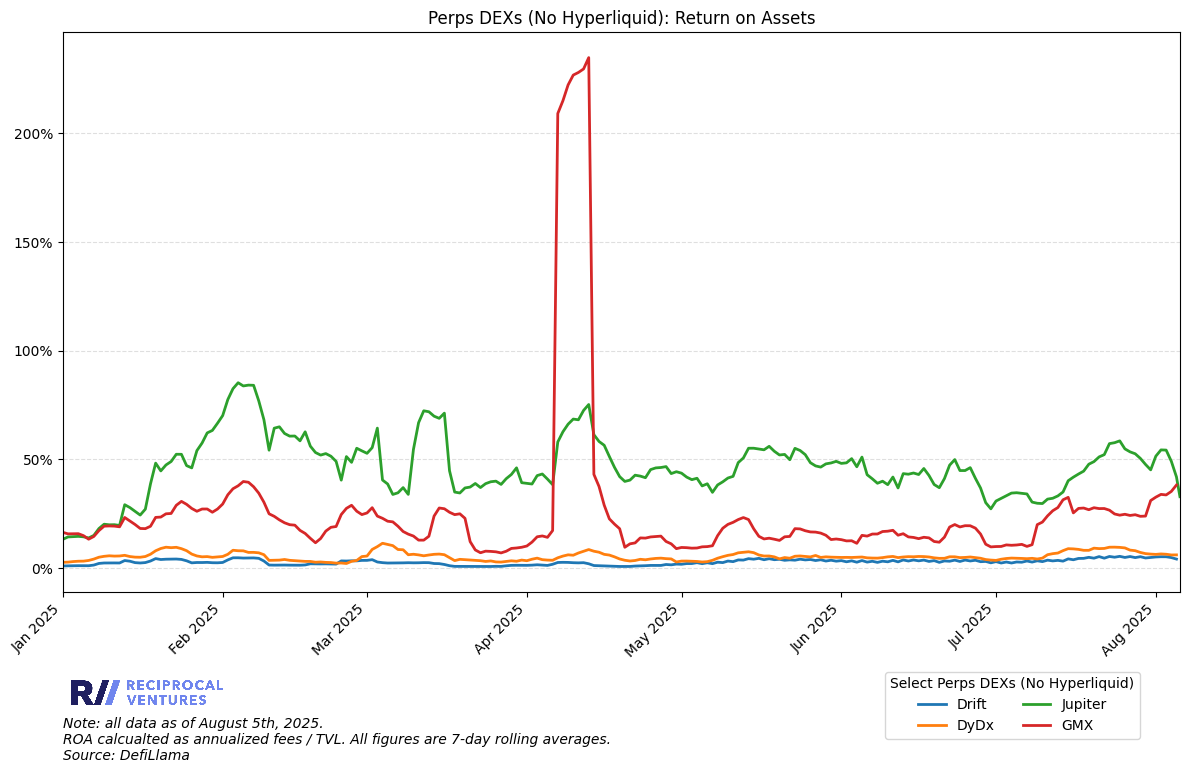


Perps DEXs (No Hyperliquid) ROA Statistics:
Median ROA: 27%
Latest ROA: 5%
Mean ROA: 31%
80th Percentile ROA: 38%
20th Percentile ROA: 18%
Standard Deviation: 22%



In [5]:
# Call the function
perps_dexs = {
          'drift': 'Drift',
          'dydx': 'DyDx',
          'jupiter': 'Jupiter',
          'gmx': 'GMX'
             }

# 'metric' should be 'Fees' or 'Revenue'
start_date = '2025-01-01'
assets = perps_dexs
metric = 'Fees'
category_title = 'Perps DEXs (No Hyperliquid)'

perps_dexs_no_hyperliquid_stats = annualized_fees_vs_TVL_asset(start_date, assets, metric, category_title)

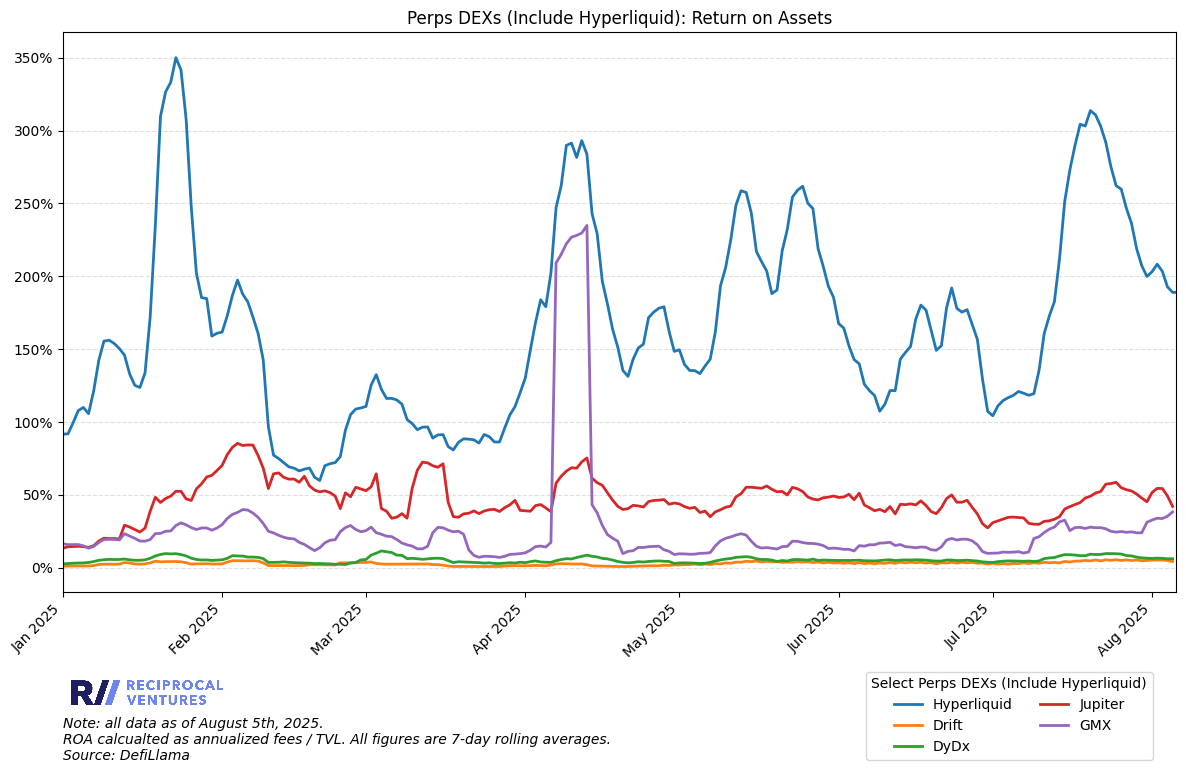


Perps DEXs (Include Hyperliquid) ROA Statistics:
Median ROA: 38%
Latest ROA: 27%
Mean ROA: 43%
80th Percentile ROA: 56%
20th Percentile ROA: 27%
Standard Deviation: 25%



In [6]:
# Call the function
perps_dexs = {'hyperliquid': 'Hyperliquid',
          'drift': 'Drift',
          'dydx': 'DyDx',
          'jupiter': 'Jupiter',
          'gmx': 'GMX'
             }

# 'metric' should be 'Fees' or 'Revenue'
start_date = '2025-01-01'
assets = perps_dexs
metric = 'Fees'
category_title = 'Perps DEXs (Include Hyperliquid)'

perps_dexs_incl_hyperliquid_stats = annualized_fees_vs_TVL_asset(start_date, assets, metric, category_title)

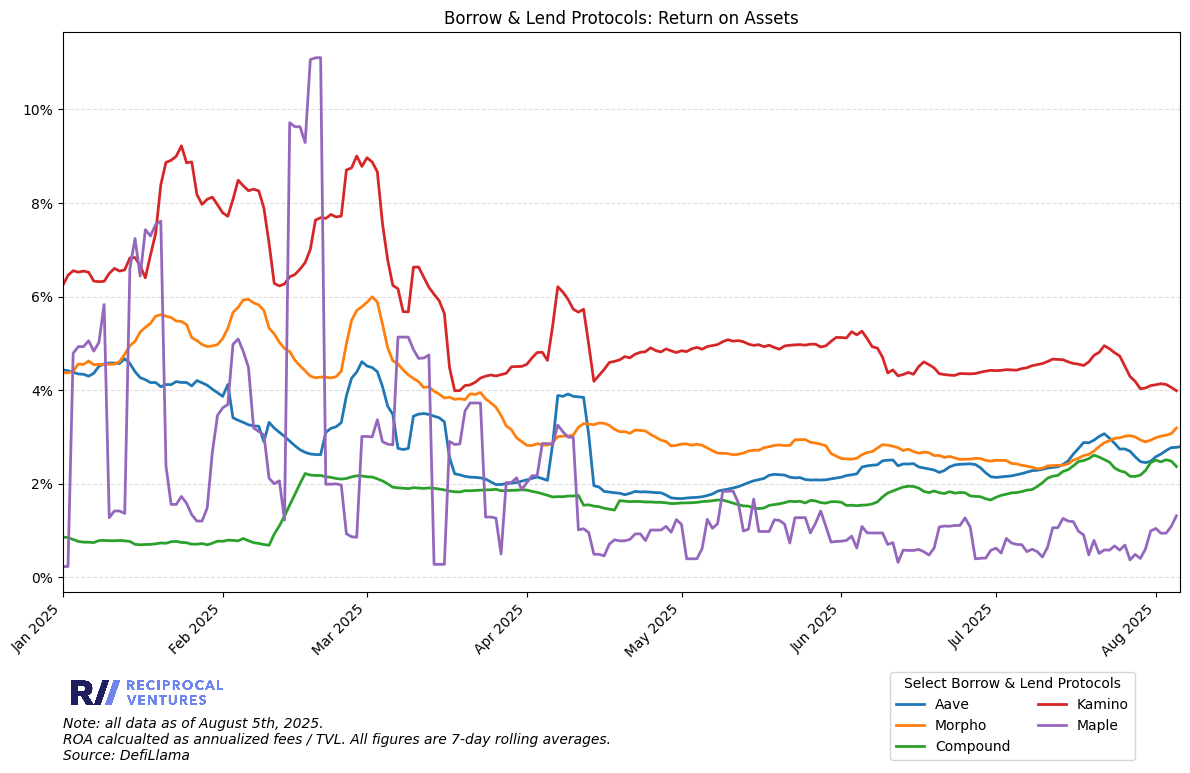


Borrow & Lend Protocols ROA Statistics:
Median ROA: 2%
Latest ROA: 3%
Mean ROA: 3%
80th Percentile ROA: 4%
20th Percentile ROA: 2%
Standard Deviation: 1%



In [7]:
# Call the function
borrow_lend_protocols = {'aave': 'Aave',
                         'morpho': 'Morpho',
                         'compound': 'Compound',
                         'kamino': 'Kamino',
                         'maple-finance': 'Maple',
                        }

# 'metric' should be 'Fees' or 'Revenue'
assets = borrow_lend_protocols
category_title = 'Borrow & Lend Protocols'

borrow_lend_stats = annualized_fees_vs_TVL_asset(start_date, assets, metric, category_title)

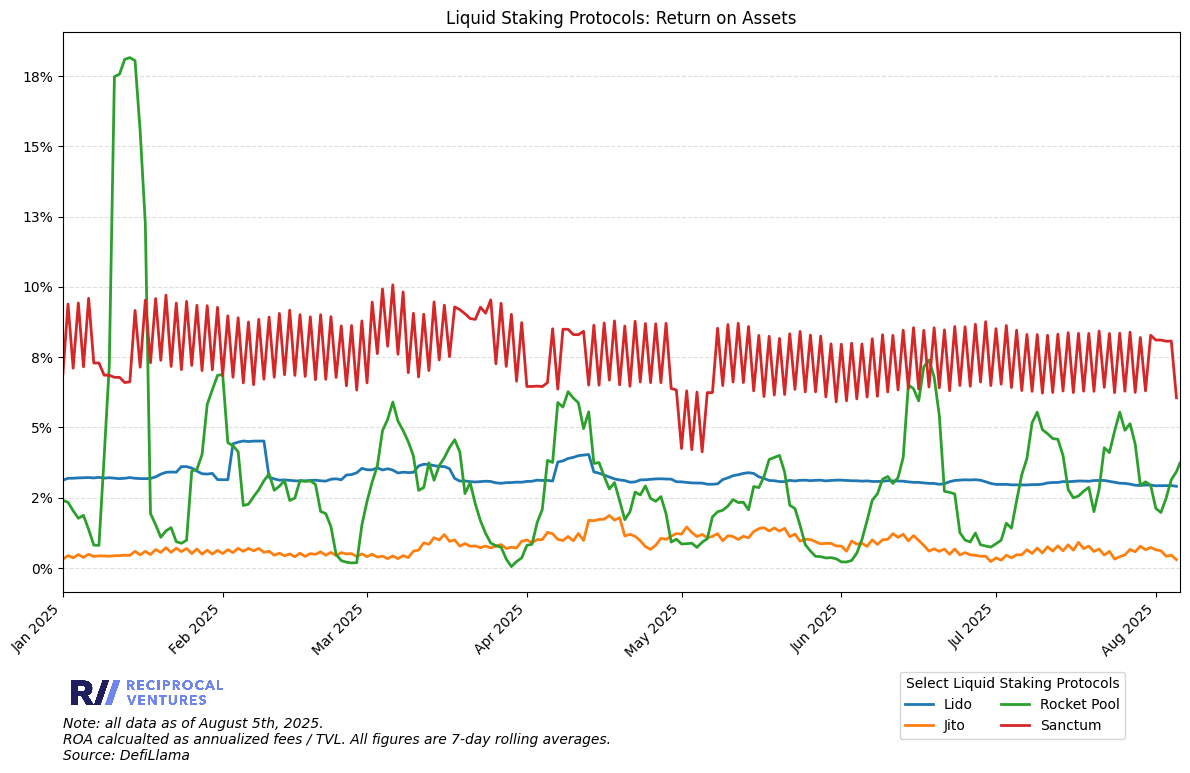


Liquid Staking Protocols ROA Statistics:
Median ROA: 3%
Latest ROA: 2%
Mean ROA: 3%
80th Percentile ROA: 4%
20th Percentile ROA: 3%
Standard Deviation: 1%



In [8]:
# Call the function
liquid_staking = {'lido': 'Lido',
                        'jito-liquid-staking': 'Jito',
                        'rocket-pool': 'Rocket Pool',
                        'sanctum-validator-lsts': 'Sanctum'
                       }

# 'metric' should be 'Fees' or 'Revenue'
assets = liquid_staking
category_title = 'Liquid Staking Protocols'

liquid_staking_stats = annualized_fees_vs_TVL_asset(start_date, assets, metric, category_title)

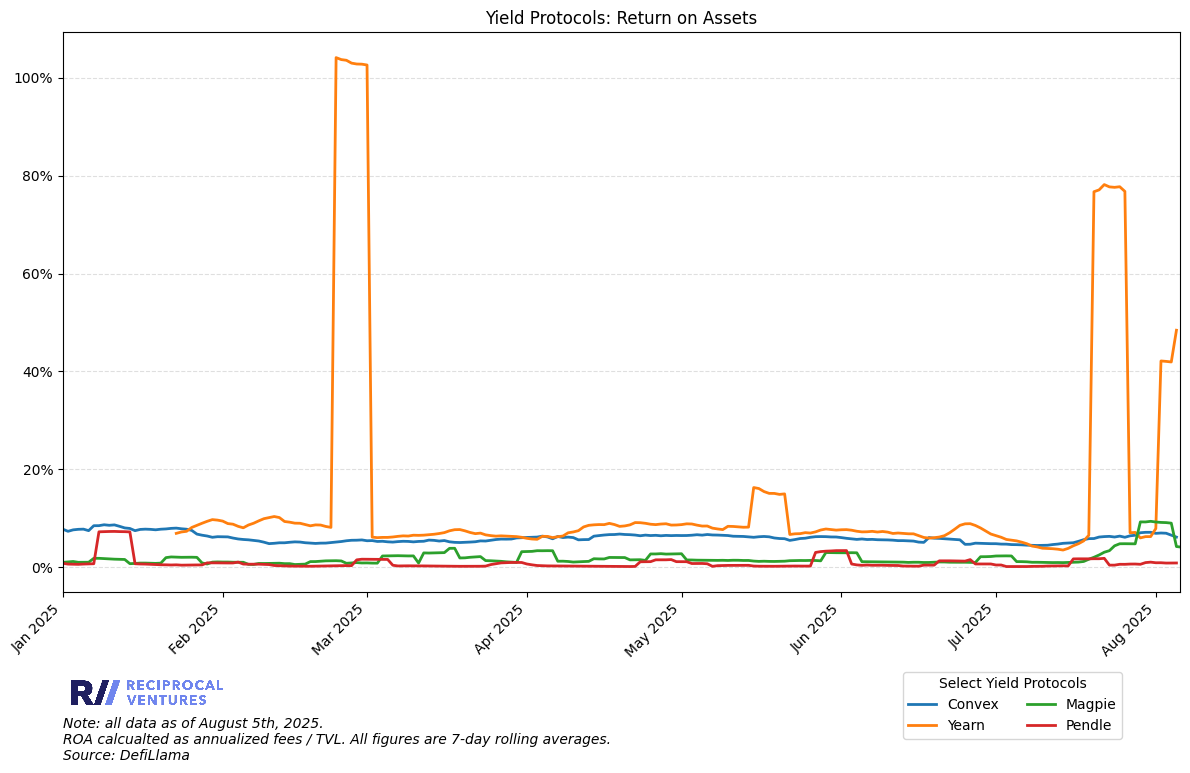


Yield Protocols ROA Statistics:
Median ROA: 2%
Latest ROA: 4%
Mean ROA: 2%
80th Percentile ROA: 2%
20th Percentile ROA: 1%
Standard Deviation: 3%



In [9]:
# Call the function
yield_protocols= {'convex-finance': 'Convex',
          'yearn-finance': 'Yearn',
          'magpie-ecosystem': 'Magpie',
          'pendle': 'Pendle'
             }

# 'metric' should be 'Fees' or 'Revenue'
assets = yield_protocols
category_title = 'Yield Protocols'

yield_stats = annualized_fees_vs_TVL_asset(start_date, assets, metric, category_title)

In [10]:
start_date = format_date_with_suffix(start_date)

combined_stats = pd.DataFrame({
    'Perps DEXs (Incl. Hyperliquid)':                perps_dexs_incl_hyperliquid_stats,
    'Perps DEXs (No Hyperliquid)': perps_dexs_no_hyperliquid_stats,
    'Borrow / Lend': borrow_lend_stats,
    'Liquid Staking': liquid_staking_stats,
    'Yield Aggregator': yield_stats

})

combined_stats.index = [
    'Median',
    'Most Recent',
    'Mean',
    '80th Percentile',
    '20th Percentile',
    'Standard Deviation'
]

# Re-order and keep only the fields I want to display
desired_order = ['Median', '80th Percentile', '20th Percentile', 'Standard Deviation']
filtered_stats = combined_stats.reindex(desired_order)

styled = (
    filtered_stats
      .style
      .set_caption("Annualized Fees / TVL by Protocol Type")
      .set_table_styles([
          {"selector": "caption",
           "props": [
             ("font-weight", "bold"),
             ("caption-side", "top"),
             ("text-decoration", "underline")
           ]},
          {"selector": "thead th", "props": [("font-weight", "normal")]},
          {"selector": "tbody th", "props": [("font-weight", "normal")]}
      ], overwrite=False)
      .format(lambda v: f"{v:,.0f}%" if pd.notnull(v) else "")
)

display(styled)


print(f"""
Notes:
 • All data from {start_date} to {date}.
 • Perp DEXs includes: Drift, dYdX, GMX, Hyperliquid, and Jupiter.
 • Borrow / Lend Protocols includes: Aave, Compound, Kamino, Maple, and Morpho.
 • Liquid Staking Protocols includes: Lido, Jito, Rocket Pool, and Sanctum.
 • Yield Aggregator Protocols includes: Convex, Magpie, Pendle, and Yearn.
 • All figures are TVL-weighted.
 
 Sources: DefiLlama.
""")

,Perps DEXs (Incl. Hyperliquid),Perps DEXs (No Hyperliquid),Borrow / Lend,Liquid Staking,Yield Aggregator
Median,38%,27%,2%,3%,2%
80th Percentile,56%,38%,4%,4%,2%
20th Percentile,27%,18%,2%,3%,1%
Standard Deviation,25%,22%,1%,1%,3%



Notes:
 • All data from January 1st, 2025 to August 5th, 2025.
 • Perp DEXs includes: Drift, dYdX, GMX, Hyperliquid, and Jupiter.
 • Borrow / Lend Protocols includes: Aave, Compound, Kamino, Maple, and Morpho.
 • Liquid Staking Protocols includes: Lido, Jito, Rocket Pool, and Sanctum.
 • Yield Aggregator Protocols includes: Convex, Magpie, Pendle, and Yearn.
 • All figures are TVL-weighted.
 
 Sources: DefiLlama.



In [22]:
def plot_tvl_single_asset(asset_slug, asset_name, start_date):
    asset_colors = ['#1f1f60',
                    '#4A5DB2',
                    '#494949',
                    '#A0A0A0'
                   ]
    # Load TVL data
    tvl_path = f"raw-data/defillama-raw-data/tvl_data/{asset_slug}_tvl.json"
    with open(tvl_path) as tvl_f:
        tvl_data = json.load(tvl_f)

    tvl_df = pd.DataFrame(
        tvl_data['tvl'],
        columns=['date', 'totalLiquidityUSD']
    )
    tvl_df.rename(columns={
        'date': 'timestamp',
        'totalLiquidityUSD': f'{asset_slug}-tvl'
    }, inplace=True)
    tvl_df['date'] = pd.to_datetime(tvl_df['timestamp'], unit='s')
    tvl_df = tvl_df[['date', f'{asset_slug}-tvl']]

    tvl_df = tvl_df.ffill()

    # Calculate trailing 7-day average
    tvl_df[f"{asset_slug}-tvl-7d"] = tvl_df[f"{asset_slug}-tvl"].rolling(window=7, min_periods=1).mean()

    df_master = tvl_df

    # Cut off df_master to only be after start date
    df_master = df_master[df_master['date'] >= start_date]
    
    # Create the line chart
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Plotting the line chart with custom colors
    ax.stackplot(
        df_master['date'], 
        df_master[f'{asset_slug}-tvl-7d'], 
        labels=asset_name, 
        colors = asset_colors
    )
    
    # Setting labels and title
    ax.set_title(f'{asset_name} TVL')
    ax.margins(x=0)
    ax.xaxis.set_major_locator(MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1e6:,.0f}m'))

    # Add grid lines for better readability
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    
    # Add logo
    add_logo(ax, position=(0.075, -0.18))
    
    # Add sources and note
    text_box = ax.text(0, -0.3, f"Note: all data as of {date}. All figures are 7-day rolling averages.\nSource: DefiLlama",
                       ha='left', transform=ax.transAxes, fontsize=10,
                       bbox=dict(facecolor='white', alpha=0), fontstyle='italic')
    
    # Ensure the layout adapts to fit all elements (legend, text, etc.)
    plt.tight_layout()
    
    # Save plot
    if not os.path.exists("plots"):
        os.makedirs("plots")
    plt.savefig(f"{plots_filepath}select-assets-tvl.png", dpi=300, bbox_inches='tight')
    
    # Show
    plt.show()

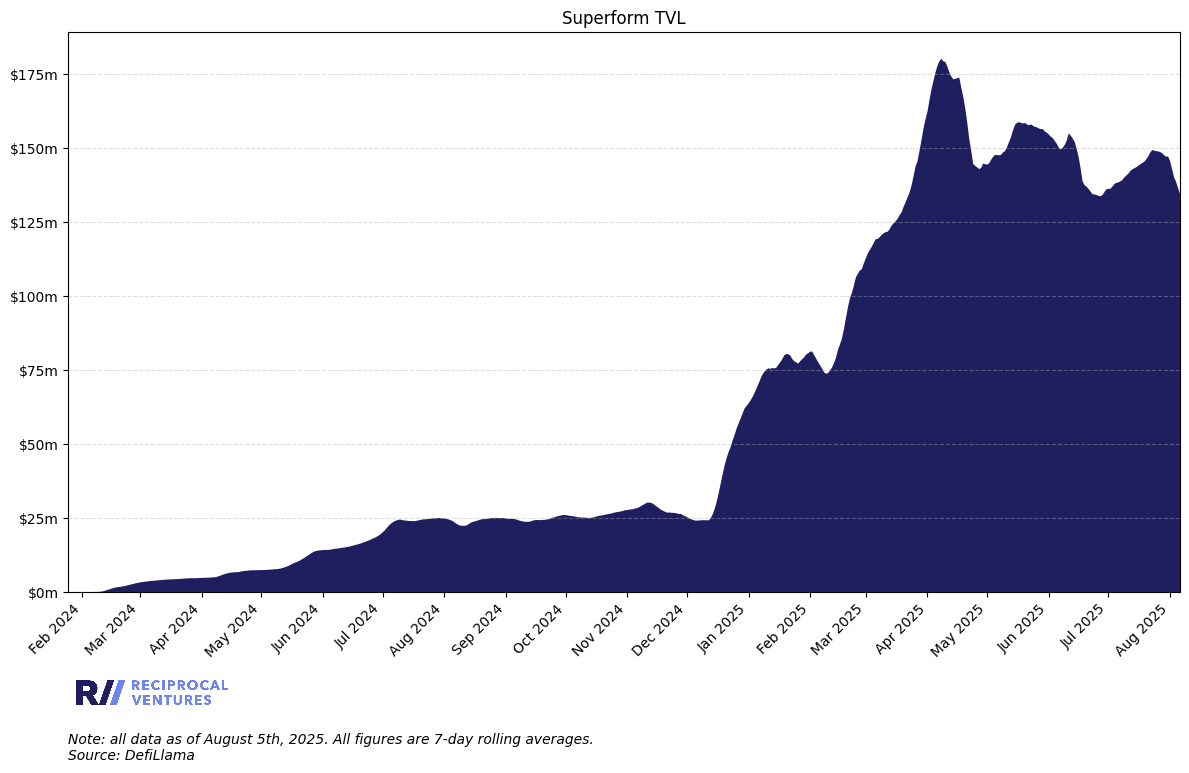

In [24]:
asset_slug = 'superform' 
asset_name = 'Superform'
start_date = '2024-01-01'

plot_tvl_single_asset(asset_slug, asset_name, start_date)